# Credit Risk Scoring System

## Problem Statement
We aim to build a credit scoring system that predicts probability of default and supports lending decisions such as approve, reject, or review.
Designed based on credit decision systems used in fintech companies like Moniepoint, Paystack, and Klarna.



## Business Objective

- Improve loan approval decisions
- Reduce default risk
- Maximize profitability of lending portfolio

In [89]:
## Lets import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

## Dataset

We use the German Credit dataset, which contains customer financial and demographic information.

### Target Variable:
- `default`:
  - 0 → Non-default (good customer)
  - 1 → Default (bad customer)

In [90]:
### Lets load the files into google collab
from google.colab import files
uploaded = files.upload()

Saving german_credit_dataset.csv to german_credit_dataset (2).csv


In [91]:
## Lets access the dataset
df = pd.read_csv('german_credit_dataset.csv')
df.head(5)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [92]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

### Exploratory data analysis

In [93]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [95]:
df.shape

(1000, 11)

In [96]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

## Data Preprocessing

- Converted target variable into binary format
- Handled missing values
- Encoded categorical variables

In [97]:
## Lets rename the first columns as its not properly named
df.rename(columns={'Unnamed: 0':'index'}, inplace=True)
df.head()

,index,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [98]:
df.columns

Index(['index', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [99]:
df["default"] = df["Risk"].map({"good": 0, "bad": 1})
df = df.drop("Risk", axis=1)



In [100]:
### Lets have an idea of how the target variable looks like...
df['default'].value_counts()

,count
default,
0,700
1,300


<Axes: xlabel='default', ylabel='count'>

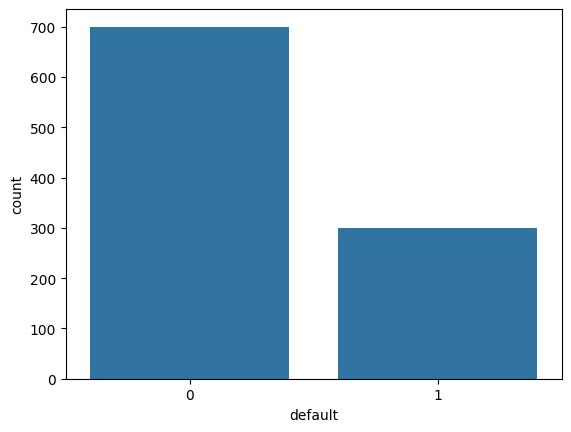

In [101]:
## lets visualize the default variable
sns.countplot(x='default', data=df)
#

### Feature Engineering

####
Lets create features that'll reflect a true credit decision system e.g
- credit burden
- Age Risk groups
- Has savings
- Has checking account
- Secret loan flags

In [102]:
## Credit burden
df['credit_per_month']  = df['Credit amount']/df['Duration']
df.head()

,index,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,default,credit_per_month
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,0,194.833333
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,1,123.979167
2,2,49,male,1,own,little,NaN,2096,12,education,0,174.666667
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,0,187.666667
4,4,53,male,2,free,little,little,4870,24,car,1,202.916667


In [103]:
### Age group risk
def age_group(age):
    if age < 25:
        return "young"
    elif age < 50:
        return "adult"
    else:
        return "senior"

df["age_group"] = df["Age"].apply(age_group)

In [104]:
df.head()

,index,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,default,credit_per_month,age_group
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,0,194.833333,senior
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,1,123.979167,young
2,2,49,male,1,own,little,NaN,2096,12,education,0,174.666667,adult
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,0,187.666667,adult
4,4,53,male,2,free,little,little,4870,24,car,1,202.916667,senior


In [105]:
df.columns

Index(['index', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'default',
       'credit_per_month', 'age_group'],
      dtype='object')

In [106]:
### Has savings (financial statbility)
df["has_savings"] = df["Saving accounts"].notnull().astype(int)

### Has checking account
df["has_checking"] = df["Checking account"].notnull().astype(int)

## Risky loan flag
df["high_loan"] = (df["Credit amount"] > df["Credit amount"].median()).astype(int)

In [107]:
df.head()

,index,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,default,credit_per_month,age_group,has_savings,has_checking,high_loan
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,0,194.833333,senior,0,1,0
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,1,123.979167,young,1,1,1
2,2,49,male,1,own,little,NaN,2096,12,education,0,174.666667,adult,1,0,0
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,0,187.666667,adult,1,1,1
4,4,53,male,2,free,little,little,4870,24,car,1,202.916667,senior,1,1,1


### Encode categorical varaibles to continous

In [108]:
df = pd.get_dummies(df, drop_first=True)

In [109]:
df.head()

,index,Age,Job,Credit amount,Duration,default,credit_per_month,has_savings,has_checking,high_loan,...,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,age_group_senior,age_group_young
0,0,67,2,1169,6,0,194.833333,0,1,0,...,False,False,False,False,False,True,False,False,True,False
1,1,22,2,5951,48,1,123.979167,1,1,1,...,False,False,False,False,False,True,False,False,False,True
2,2,49,1,2096,12,0,174.666667,1,0,0,...,False,False,False,True,False,False,False,False,False,False
3,3,45,2,7882,42,0,187.666667,1,1,1,...,False,False,False,False,True,False,False,False,False,False
4,4,53,2,4870,24,1,202.916667,1,1,1,...,False,True,False,False,False,False,False,False,True,False


In [110]:
df.columns

Index(['index', 'Age', 'Job', 'Credit amount', 'Duration', 'default',
       'credit_per_month', 'has_savings', 'has_checking', 'high_loan',
       'Sex_male', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate',
       'Saving accounts_quite rich', 'Saving accounts_rich',
       'Checking account_moderate', 'Checking account_rich', 'Purpose_car',
       'Purpose_domestic appliances', 'Purpose_education',
       'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs',
       'Purpose_vacation/others', 'age_group_senior', 'age_group_young'],
      dtype='object')

### Scale numerical features

In [119]:
scalar = StandardScaler()

X = df.drop('default', axis = 1)
y = df['default']

X_scaled = scalar.fit_transform(X)

### Train Test Split

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [121]:
X_train

array([[-1.62986062,  2.41464667,  0.14694918, ..., -0.11020775,
         2.64575131, -0.41843534],
       [ 0.12297567, -0.22392695,  0.14694918, ..., -0.11020775,
        -0.37796447, -0.41843534],
       [ 0.6772322 ,  1.27126477,  0.14694918, ..., -0.11020775,
         2.64575131, -0.41843534],
       ...,
       [ 1.24880926, -0.75164167,  0.14694918, ..., -0.11020775,
        -0.37796447, -0.41843534],
       [-0.22343467, -0.92754658,  0.14694918, ..., -0.11020775,
        -0.37796447, -0.41843534],
       [-1.37698108, -1.01549903,  0.14694918, ..., -0.11020775,
        -0.37796447,  2.38985552]])

## Model Selection

We use Logistic Regression, a standard model in credit risk due to its interpretability and effectiveness.

In [122]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Model Evaluation

We evaluate the model using ROC-AUC, which measures how well the model distinguishes between defaulters and non-defaulters.

In [123]:
y_prob = model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_prob)

np.float64(0.7744921264575069)

### Result
The model achieved a ROC-AUC score of approximately **0.77**, indicating good predictive performance for a baseline credit model.

## Credit Scoring System

We convert predicted probabilities into credit scores ranging from 300 to 850.

- Higher score → Lower risk  
- Lower score → Higher risk  

In [124]:
## create a credit score
def credit_score(prob):
    return int((1 - prob) * 550 + 300)

In [125]:
### Apply the credit score
df["pd"] = model.predict_proba(X_scaled)[:, 1]  # Probability of default
df["credit_score"] = df["pd"].apply(credit_score)

df[["pd", "credit_score"]].head()

,pd,credit_score
0,0.069133,811
1,0.599930,520
2,0.079281,806
3,0.576724,532
4,0.490819,580


## Risk Segmentation

Customers are grouped into risk categories:

- 700+ → Low Risk  
- 600–699 → Medium Risk  
- <600 → High Risk  

In [126]:
def risk_band(score):
    if score >= 700:
        return "Low Risk"
    elif score >= 600:
        return "Medium Risk"
    else:
        return "High Risk"

df["risk_band"] = df["credit_score"].apply(risk_band)

### Check distribution

In [127]:
df["risk_band"].value_counts()

,count
risk_band,
Low Risk,543
High Risk,244
Medium Risk,213


## Lending Decision System

We simulate lending decisions based on risk:

- APPROVE → Low risk customers  
- REJECT → High risk customers  

In [128]:
def decision(score):
    if score >= 700:
        return "APPROVE"
    elif score >= 600:
        return "REVIEW"
    else:
        return "REJECT"

df["decision"] = df["credit_score"].apply(decision)

In [129]:
df[["credit_score", "risk_band", "decision"]].head()

,credit_score,risk_band,decision
0,811,Low Risk,APPROVE
1,520,High Risk,REJECT
2,806,Low Risk,APPROVE
3,532,High Risk,REJECT
4,580,High Risk,REJECT


## Business Impact Simulation

We simulate the financial outcome of lending decisions.

- Profit from good loans (interest)
- Loss from defaults

In [130]:
loan_amount = 1000
interest_rate = 0.2

def profit(row):
    if row["decision"] == "APPROVE":
        if row["default"] == 0:
            return loan_amount * interest_rate
        else:
            return -loan_amount
    return 0

df["profit"] = df.apply(profit, axis=1)

df["profit"].sum()

np.float64(27000.0)

## Threshold Optimization

Instead of fixed rules, we optimize the approval threshold to maximize profit.

In [131]:


def calculate_profit(y_true, y_prob, threshold):
    profit = 0
    for i in range(len(y_true)):
        if y_prob[i] < threshold:
            if y_true.iloc[i] == 0:
                profit += 200
            else:
                profit -= 1000
    return profit

thresholds = np.linspace(0.1, 0.9, 50)
profits = [calculate_profit(y_test.reset_index(drop=True), y_prob, t) for t in thresholds]

best_threshold = thresholds[np.argmax(profits)]
best_threshold

np.float64(0.1816326530612245)

### Visualization

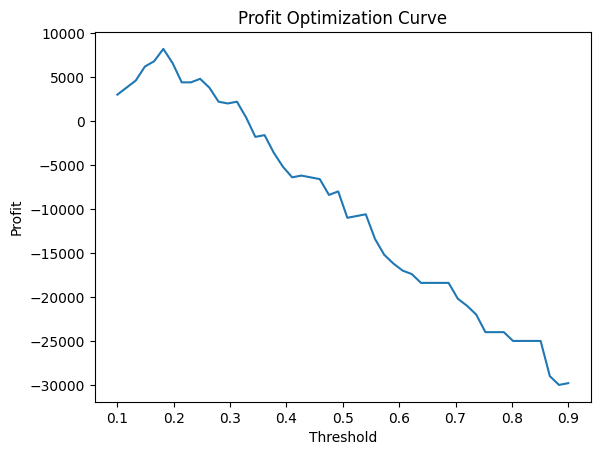

In [132]:
plt.plot(thresholds, profits)
plt.xlabel("Threshold")
plt.ylabel("Profit")
plt.title("Profit Optimization Curve")
plt.show()

## Conclusion

This project demonstrates how machine learning can be applied to credit risk modeling.

Key achievements:

- Built a Probability of Default (PD) model  
- Developed a credit scoring system  
- Implemented risk segmentation  
- Simulated lending decisions  
- Optimized thresholds for maximum profitability  

This approach mirrors real-world fintech systems used in digital lending platforms.